# Notebook Dedicated to Build the real data distribution vs the MC model of B8 Solar Nue + Tl208

In [2]:
import numpy as np
import scipy.stats as stats

import glob
import re
import os
import pickle

import seaborn as sn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from matplotlib.font_manager import FontProperties
from matplotlib import font_manager
from matplotlib import cm

# Functions

## Log-likelihood Fit

In [3]:
def calc_poisson_likelihood_chi2(mc_count, data_count):
    
    """
    Compute the -2 ln(Lambda) of Baker-Cousins.
    
    Parameters:
    - mc_count: predicted model counts
    - data_count: observed real data couns

    Return:
    - total chi^2 naker-Cousin Likelihood
    - chi^2 value for each bin
    - pull/oscilaltions between model and data observation according to the likelihood formula
    """
    
    O = np.asarray(data_count, dtype=float)  # Observed
    E = np.asarray(mc_count, dtype=float)    # Expected
    
    # 3. Inicializar el término del logaritmo en ceros
    log_term = np.zeros_like(O)
    
    # Avoid zero counting
    mask_non_0 = (O > 0)
    log_term[mask_non_0] = O[mask_non_0] * np.log(O[mask_non_0] / E[mask_non_0])
    
    # Likelihood for each bin
    chi2_lambda_terms = 2 * (E[mask_non_0] - O[mask_non_0] + log_term[mask_non_0])
    
    # Total Likelohood/fit value
    chi2_lambda_total = np.sum(chi2_lambda_terms)

    # Pull values between model and data: How MC and Data model diference oscillate
    pull = (np.sign(O[mask_non_0]-E[mask_non_0]))*np.sqrt(chi2_lambda_terms)

    return chi2_lambda_total, chi2_lambda_terms, pull

# Load the Data

In [4]:
# ------- Observable list -------

#Define the name of the observables to be loaded. It will be applied to MC and Data, correspondingly
obs_list_solar_mc = ['posr_av', 'posx', 'posy', 'posz_av', 'n_init_evs', 'energy_corrected',]
obs_list_tl208_mc = ['posr_av', 'posx', 'posy', 'posz_av', 'n_init_evs', 'energy_corrected']
obs_list_data = ['energy', 'posr_av', 'posx', 'posy', 'posz_av', 'energy_corrected', 'itr']

## General Cuts Definition

In [5]:
posr_cut = 5500
en_inf_cut = 5
itr_cut = 0.20

## MC Data

### $\nu_e$ Boron-8

In [6]:
#main_dir = '/home/joankl/data/solars/mc/bisMSB/b8Nue/non_osc/np_array_resume/'
main_dir = 'E:/Data/solars/mc/2p2PPO/b8Nue/non_osc/np_array_resume/'

# ------- Observable Dictionary -------
obs_dict_b8_Nue_mc = {obs: np.array([]) for obs in obs_list_solar_mc}

# ------- Load and save observables in dictionary -------
for obs in obs_list_solar_mc:
    obs_i = np.load(main_dir + obs + '.npy')
    obs_dict_b8_Nue_mc[obs] = np.append(obs_dict_b8_Nue_mc[obs], obs_i)

# ---- Cut Condition ----
cut_condition = (obs_dict_b8_Nue_mc['posr_av'] <= posr_cut) & (obs_dict_b8_Nue_mc['energy_corrected'] >= en_inf_cut)

# ---- Choose observables ----
n_init_evs_b8_Nue_mc = obs_dict_b8_Nue_mc['n_init_evs']
#energy_b8_Nue_mc = obs_dict_b8_Nue_mc['energy'][cut_condition]
energy_corr_b8_Nue_mc = obs_dict_b8_Nue_mc['energy_corrected'][cut_condition]
#Pee_b8_Nue_mc = obs_dict_b8_Nue_mc['Pee'][cut_condition]

### $\nu_e$ Boron-8 with Rejection Sampling to simulate Oscillations

In [7]:
#main_dir = '/home/joankl/data/solars/mc/bisMSB/b8Nue/osc/np_array_resume/'
main_dir = 'E:/Data/solars/mc/2p2PPO/b8Nue/osc/np_array_resume/'

# ------- Observable Dictionary -------
obs_dict_b8_Nue_mc = {obs: np.array([]) for obs in obs_list_solar_mc + ['energy_corrected']}

# ------- Load and save observables in dictionary -------
for obs in obs_list_tl208_mc:
    obs_i = np.load(main_dir + obs + '.npy')
    obs_dict_b8_Nue_mc[obs] = np.append(obs_dict_b8_Nue_mc[obs], obs_i)

# ---- Cut Condition ----
cut_condition = (obs_dict_b8_Nue_mc['posr_av'] <= posr_cut) & (obs_dict_b8_Nue_mc['energy_corrected'] >= en_inf_cut)

# ---- Choose observables ----
n_init_evs_b8_osc_Nue_mc_rs = obs_dict_b8_Nue_mc['n_init_evs']
#energy_b8_osc_Nue_mc_rs = obs_dict_b8_Nue_mc['energy'][cut_condition]
energy_corr_b8_osc_Nue_mc_rs = obs_dict_b8_Nue_mc['energy_corrected'][cut_condition]

In [8]:
n_init_evs_b8_osc_Nue_mc_rs

array([64867., 65303., 65575., 65075., 65042., 65008., 65191., 65179.,
       65059., 65210., 65117., 62563., 65951., 64841., 65649., 65169.,
       65716., 65196., 64862., 66207., 65561., 65312., 64300., 64659.,
       65188., 65462., 65782., 41981., 64052., 65248., 65522., 65431.,
       64769., 65107., 63990., 64185., 65547., 65289., 65942., 65874.,
       65560.])

### $\nu_\mu$ Boron-8

In [9]:
#main_dir = '/home/joankl/data/solars/mc/bisMSB/b8Numu/osc/np_array_resume/'
main_dir = 'E:/Data/solars/mc/2p2PPO/b8Numu/osc/np_array_resume/'

# ------- Observable Dictionary -------
obs_dict_b8_Numu_mc = {obs: np.array([]) for obs in obs_list_solar_mc}

# ------- Load and save observables in dictionary -------
for obs in obs_list_solar_mc:
    obs_i = np.load(main_dir + obs + '.npy')
    obs_dict_b8_Numu_mc[obs] = np.append(obs_dict_b8_Numu_mc[obs], obs_i)

# ---- Cut Condition ----
cut_condition = (obs_dict_b8_Numu_mc['posr_av'] <= posr_cut) & (obs_dict_b8_Numu_mc['energy_corrected'] >= en_inf_cut)

# ---- Choose observables ----
n_init_evs_b8_Numu_mc = obs_dict_b8_Numu_mc['n_init_evs']
#energy_b8_Numu_mc = obs_dict_b8_Numu_mc['energy'][cut_condition]
energy_corr_b8_Numu_mc = obs_dict_b8_Numu_mc['energy_corrected'][cut_condition]
#Pee_b8_Numu_mc = obs_dict_b8_Numu_mc['Pee'][cut_condition]

### Tl208

In [10]:
main_dir = 'E:/Data/solars/mc/2p2PPO/tl208/np_array_resume/'
#main_dir = '/home/joankl/data/solars/mc/bisMSB/tl208/np_array_resume/'

# ------- Observable Dictionary -------
obs_dict_tl208_mc = {obs: np.array([]) for obs in obs_list_tl208_mc}

# ------- Load and save observables in dictionary -------
for obs in obs_list_tl208_mc:
    obs_i = np.load(main_dir + obs + '.npy')
    obs_dict_tl208_mc[obs] = np.append(obs_dict_tl208_mc[obs], obs_i)

# ---- Cut Condition ----
cut_condition = (obs_dict_tl208_mc['posr_av'] <= posr_cut)  & (obs_dict_tl208_mc['energy_corrected'] >= en_inf_cut)

# ---- Choose observables ----
#energy_tl208_mc = obs_dict_tl208_mc['energy'][cut_condition]
energy_corr_tl208_mc = obs_dict_tl208_mc['energy_corrected'][cut_condition]
n_init_evs_tl208_mc = obs_dict_tl208_mc['n_init_evs']

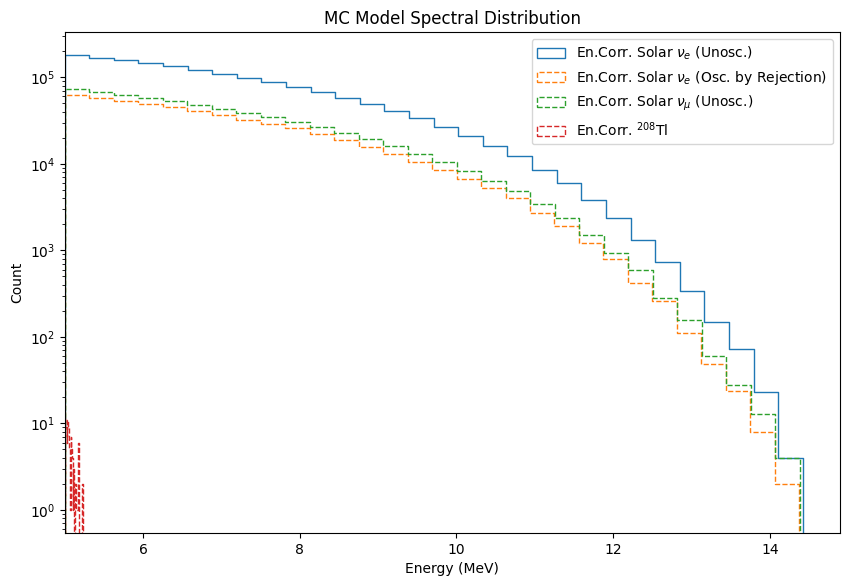

In [36]:
plt.figure(figsize = (10, 6.5))

bins = 30

#sn.histplot(energy_b8_Nue_mc, bins = bins, element = 'step', alpha = 0, label = r'Solar $\nu_e$ (Unosc.)')
#sn.histplot(x = energy_b8_Nue_mc, bins = bins, element = 'step', alpha = 0, weights = Pee_b8_Nue_mc , label = r'Solar $\nu_e$ (Osc.)')
#sn.histplot(x = energy_b8_osc_Nue_mc_rs, bins = bins, element = 'step', alpha = 0 , label = r'Solar $\nu_e$ (Osc. by Rejection)')
#sn.histplot(energy_b8_Numu_mc, bins = bins, element = 'step', alpha = 0, label = r'Solar $\nu_\mu$ (Unosc.)')
#sn.histplot(x = energy_b8_Numu_mc, bins = bins, element = 'step', alpha = 0, weights = Pee_b8_Numu_mc, label = r'Solar $\nu_\mu$ (Osc.)')
#sn.histplot(energy_tl208_mc, bins = bins, element = 'step', alpha = 0, label = '$^{208}$Tl')

sn.histplot(energy_corr_b8_Nue_mc, bins = bins, element = 'step', alpha = 0, label = r'En.Corr. Solar $\nu_e$ (Unosc.)')
sn.histplot(x = energy_corr_b8_osc_Nue_mc_rs, bins = bins, element = 'step', alpha = 0 , linestyle="--", label = r'En.Corr. Solar $\nu_e$ (Osc. by Rejection)')
sn.histplot(energy_corr_b8_Numu_mc, bins = bins, element = 'step', alpha = 0, linestyle="--", label = r'En.Corr. Solar $\nu_\mu$ (Unosc.)')
#sn.histplot(x = energy_corr_b8_Numu_mc, bins = bins, element = 'step', alpha = 0, weights = Pee_b8_Numu_mc, linestyle="--", label = r'En.Corr. Solar $\nu_\mu$ (Osc.)')
sn.histplot(energy_corr_tl208_mc, bins = bins, element = 'step', alpha = 0, linestyle="--", label = 'En.Corr. $^{208}$Tl')

plt.xlabel('Energy (MeV)')

plt.yscale('log')
plt.legend(loc = 'best')

plt.title('MC Model Spectral Distribution')

plt.xlim(5,)

plt.show()

## Real Data

In [11]:
# ------- Observable list -------
obs_list = ['energy_corrected', 'posr_av', 'posx', 'posy', 'posz_av', 'runID', 'itr', 'eventID']

# ------- Observable Dictionary -------
obs_dict = {obs: np.array([]) for obs in obs_list}

# ------- Directory of data -------
#candidates_data_dir = '/home/joankl/data/solars/real_data/2p2PPO/candidates/resume_files/'
candidates_data_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/first_candidates/ntuple/resume_files/'

#hs_dir = '/home/joankl/data/solars/real_data/2p2PPO/HS_results/pkl_resume/'
hs_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/HS_results/pkl_resume/'

# Loop over the observable list to load the candidates data in obs_dict
for obs in obs_list:
    
    obs_dir = candidates_data_dir + obs + '.npy'
    obs_i = np.load(obs_dir)
    obs_dict[obs] = np.append(obs_dict[obs], obs_i)

print(f'Nº of intial events : {len(obs_dict['energy_corrected'])}')

# ===== Apply General Cuts =====
en_inf_cut = 5
posr_cut = 5500

energy_condition = (obs_dict['energy_corrected'] >= en_inf_cut)
posr_condition = (obs_dict['posr_av'] <= posr_cut)
runID_condition = (obs_dict['runID'] > 301000)
itr_condition = (obs_dict['itr'] >= 0.20)

mask = (energy_condition & posr_condition & runID_condition & itr_condition)

energy = obs_dict['energy_corrected'][mask]
posr_av = obs_dict['posr_av'][mask]
posx = obs_dict['posx'][mask]
posy = obs_dict['posy'][mask]
posz = obs_dict['posz_av'][mask]
runID = obs_dict['runID'][mask]
itr = obs_dict['itr'][mask]
eventID = obs_dict['eventID'][mask]

print(f'Nº of events after basic cuts: {len(energy)}')

# ===== Now Apply Hotspot Cuts =====

# Load HS results
with open(hs_dir + 'hs_prompt_resume.pkl', 'rb') as f:
    hs_prompt_dict = pickle.load(f)
    
    hs_prompt_eventID = hs_prompt_dict['eventID']
    hs_prompt_runID = hs_prompt_dict['runID']
    
with open(hs_dir + 'hs_delay_resume.pkl', 'rb') as f:
    hs_delay_dict = pickle.load(f)
    
    hs_delay_eventID = hs_delay_dict['eventID']
    hs_delay_runID = hs_delay_dict['runID']

hs_eventID = np.concatenate((hs_prompt_eventID, hs_delay_eventID))
hs_runID = np.concatenate((hs_prompt_runID, hs_delay_runID))

# Remove coincident eventID and runID events with tagged HS eventID and runID
# Create an unique number such that runID*offset + eventID is an unique number

offset = np.int64(10**10)

unique_id_data = (runID.astype(np.int64) * offset) + eventID.astype(np.int64)
unique_id_hs = (hs_runID.astype(np.int64) * offset) + hs_eventID.astype(np.int64)

is_hotspot = np.isin(unique_id_data, unique_id_hs)

hs_cut = ~is_hotspot

# Select the data
energy_corr_data = energy[hs_cut]

Nº of intial events : 33543
Nº of events after basic cuts: 174


In [12]:
len(energy_corr_data)

173

In [14]:
len(energy_corr_b8_osc_Nue_mc_rs)

542699

In [16]:
len(energy_corr_b8_osc_Nue_mc_rs)

542699

# MC Data Scaling Factors

Note: Before representing the MC with oscillations, lets only use the non-oscillated MC but use the number of expected events considering oscillations

In [19]:
# ======= Definition of Important Quantities =======

# ------ Dataset Lifetime ------
dataset_lf_time = 220.9362717351389  # days
#dataset_lf_time = 221.0155541425463  # days

# ------ Expected event rate per day ------
N_b8_unosc_Nue_per_day = 2483.56/365 # nue without oscillations
N_b8_osc_Nue_per_day = 862.65/365 # nue with oscillations
N_b8_Numu_per_day = 289.10/365  # numu after oscillation
N_tl208_per_day = 2.576448     

# ------ MC selection efficiency ------
# 8B Nue
n_init_evs_b8_Nue = np.sum(n_init_evs_b8_Nue_mc)
n_final_evs_b8_Nue = len(energy_corr_b8_Nue_mc)
eff_mc_b8_Nue = n_final_evs_b8_Nue / n_init_evs_b8_Nue

# 8B Nue with Rejection Sampling
n_init_evs_b8_osc_Nue_rs = np.sum(n_init_evs_b8_osc_Nue_mc_rs)
n_final_evs_b8_osc_Nue_rs = len(energy_corr_b8_osc_Nue_mc_rs)
eff_mc_b8_osc_Nue_rs = n_final_evs_b8_osc_Nue_rs / n_init_evs_b8_osc_Nue_rs

# 8B Numu
n_init_evs_b8_Numu = np.sum(n_init_evs_b8_Numu_mc)
n_final_evs_b8_Numu = len(energy_corr_b8_Numu_mc)
eff_mc_b8_Numu = n_final_evs_b8_Numu / n_init_evs_b8_Numu

# Tl208
n_init_evs_tl208 = np.sum(n_init_evs_tl208_mc)
n_final_evs_tl208 = len(energy_corr_tl208_mc)
eff_mc_tl208 = n_final_evs_tl208 / n_init_evs_tl208

# ------ Nº of expected events within Lifetime and cuts ------
N_scaled_mc_b8_unosc_Nue = dataset_lf_time * N_b8_unosc_Nue_per_day * eff_mc_b8_Nue
N_scaled_mc_b8_osc_Nue = dataset_lf_time * N_b8_osc_Nue_per_day * eff_mc_b8_Nue
N_scaled_mc_b8_osc_Nue_rs = dataset_lf_time * N_b8_osc_Nue_per_day * eff_mc_b8_osc_Nue_rs
N_scaled_mc_b8_Numu = dataset_lf_time * N_b8_Numu_per_day * eff_mc_b8_Numu
N_scaled_mc_tl208 = dataset_lf_time * N_tl208_per_day * eff_mc_tl208

# ------ Scaling factors: weight to mc histograms ------
scaling_mc_b8_unosc_Nue = N_scaled_mc_b8_unosc_Nue/n_final_evs_b8_Nue
scaling_mc_b8_osc_Nue = N_scaled_mc_b8_osc_Nue/n_final_evs_b8_Nue
scaling_mc_b8_osc_Nue_rs = N_scaled_mc_b8_osc_Nue_rs/n_final_evs_b8_osc_Nue_rs
scaling_mc_b8_osc_Numu = N_scaled_mc_b8_Numu/n_final_evs_b8_Numu
scaling_mc_tl208 = N_scaled_mc_tl208/n_final_evs_tl208

# ========= Print Quantites =========
print(F'====== For a Dataset Lifetime = {dataset_lf_time:.2f} days ======')
print(f'The expected B8 Nue unoscillated events are {N_scaled_mc_b8_unosc_Nue:.3f} with selection efficiency = {eff_mc_b8_Nue}')
print(f'The expected B8 Nue oscillated events are {N_scaled_mc_b8_osc_Nue:.3f} with selection efficiency = {eff_mc_b8_Nue}')
print(f'The expected B8 Nue oscillated events (with rejection sampling) are {N_scaled_mc_b8_osc_Nue_rs:.3f} with selection efficiency = {eff_mc_b8_osc_Nue_rs}')
print(f'The expected B8 Numu events are {N_scaled_mc_b8_Numu:.3f} with selection efficiency = {eff_mc_b8_Numu}')
print(f'The expected Tl208 events are {N_scaled_mc_tl208} with selection efficiency = {eff_mc_tl208}')


print(f'==== Boron-8 Nue + Numu Expected Events ====')
print(f'{N_scaled_mc_b8_osc_Nue_rs + N_scaled_mc_b8_Numu:3f} events')
print(f'==== Total Number of Expected Events ====')
print(f'{N_scaled_mc_b8_osc_Nue_rs + N_scaled_mc_b8_Numu + N_scaled_mc_tl208:3f} events')
print(f'==== Observed Events ====')
print(f'{len(energy_corr_data)} events')

====== For a Dataset Lifetime = 220.94 days ======
The expected B8 Nue unoscillated events are 324.822 with selection efficiency = 0.21607099049818182
The expected B8 Nue oscillated events are 112.825 with selection efficiency = 0.21607099049818182
The expected B8 Nue oscillated events (with rejection sampling) are 107.035 with selection efficiency = 0.2049822835604812
The expected B8 Numu events are 34.536 with selection efficiency = 0.19735757740704885
The expected Tl208 events are 0.05858975070231678 with selection efficiency = 0.00010292793206756484
==== Boron-8 Nue + Numu Expected Events ====
141.571146 events
==== Total Number of Expected Events ====
141.629736 events
==== Observed Events ====
173 events


# Data Distribution

In [40]:
save_path = 'figs/above_5_MeV_solar_results/'

### - Plot Settings and Styles

In [41]:
font_style_title = {'family':'serif', 'weight': 'normal','color':'black','size':13}
font_style_axis= {'family':'serif', 'weight': 'normal','color':'black','size':12}

font_prop = font_manager.FontProperties(family=font_style_axis['family'], weight=font_style_axis['weight'], size=10)

### - Tick marker function

Function to plot tick markers on the axis of a plot. Initially, it will be used for the spectral plots

In [42]:
def set_ticks(ax):
    # ---- X axis ----
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.xaxis.set_major_formatter(ScalarFormatter(1))

    # ---- Y axis ----
    #ax.yaxis.set_minor_locator(MultipleLocator(5))
    #ax.yaxis.set_major_formatter(ScalarFormatter())

    # ---- Show ticks on all sides ----
    ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
    ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

## Energy

### Compute the Histograms Quantities

In [43]:
# ----------------------------
# Common Bins Definition
# ----------------------------
binwidth = 0.18
linewidth = 1.1

energy_bins = list(np.arange(min(energy_corr_data),
                             max(energy_corr_data) + binwidth,
                             binwidth))  #These are the energy bin edges

bins_center_energy = (np.array(energy_bins)[:-1] + np.array(energy_bins)[1:])/2


# ============== Histogram Computation ===============

# ------  MC Distribution ------
counts_B8_unosc_Nue_mc, _ = np.histogram(energy_corr_b8_Nue_mc, bins = energy_bins, weights = np.ones(len(energy_corr_b8_Nue_mc)) * scaling_mc_b8_unosc_Nue)
#counts_B8_unosc_Nue_mc, _ = np.histogram(energy_b8_Nue_mc, bins = energy_bins, weights = np.ones(len(energy_b8_Nue_mc)) * scaling_mc_b8_unosc_Nue)

counts_B8_osc_Nue_mc, _ = np.histogram(energy_corr_b8_osc_Nue_mc_rs, bins = energy_bins, weights = np.ones(len(energy_corr_b8_osc_Nue_mc_rs))*scaling_mc_b8_osc_Nue_rs)
#counts_B8_osc_Nue_mc, _ = np.histogram(energy_b8_Nue_mc, bins = energy_bins, weights = Pee_b8_Nue_mc * scaling_mc_b8_osc_Nue)
#counts_B8_osc_Nue_mc, _ = np.histogram(energy_b8_Nue_mc, bins = energy_bins, weights = np.ones(len(energy_b8_Nue_mc))*scaling_mc_b8_osc_Nue)
#counts_B8_osc_Nue_mc, _ = np.histogram(energy_b8_Nue_mc, bins = energy_bins, weights = Pee_b8_Nue_mc*scaling_mc_b8_unosc_Nue)
#counts_B8_osc_Nue_mc, _ = np.histogram(energy_b8_osc_Nue_mc_rs, bins = energy_bins, weights = np.ones(len(energy_b8_osc_Nue_mc_rs))*scaling_mc_b8_osc_Nue_rs)

#counts_B8_unosc_Numu_mc, _ = np.histogram(energy_b8_Numu_mc, bins = energy_bins, weights = np.ones(len(energy_b8_Numu_mc)) * scaling_mc_b8_osc_Numu)

counts_B8_osc_Numu_mc, _ = np.histogram(energy_corr_b8_Numu_mc, bins = energy_bins, weights = np.ones(len(energy_corr_b8_Numu_mc)) * scaling_mc_b8_osc_Numu)
#counts_B8_osc_Numu_mc, _ = np.histogram(energy_b8_Numu_mc, bins = energy_bins, weights = np.ones(len(energy_b8_Numu_mc)) * scaling_mc_b8_osc_Numu)
#counts_B8_osc_Numu_mc, _ = np.histogram(energy_b8_Numu_mc, bins = energy_bins, weights = (1 - Pee_b8_Numu_mc) * scaling_mc_b8_osc_Numu)

#counts_tl208_mc, _ = np.histogram(energy_corr_tl208_mc, bins = energy_bins, weights = np.ones(len(energy_corr_tl208_mc)) * scaling_mc_tl208)
#counts_tl208_mc, _ = np.histogram(energy_tl208_mc, bins = energy_bins, weights = np.ones(len(energy_tl208_mc)) * scaling_mc_tl208)

#  Total MC 
#total_mc_counts = counts_B8_osc_Nue_mc + counts_B8_unosc_Numu_mc + counts_tl208_mc
total_mc_counts = counts_B8_osc_Nue_mc + counts_B8_osc_Numu_mc #+ counts_tl208_mc

# ------ Real Data Distribution Points ------
energy_counts, edges = np.histogram(energy_corr_data, bins = energy_bins)
bins_center_energy = (edges[:-1] + edges[1:])/2
error_bars = np.sqrt(energy_counts)

# Remove zero count points in real data
bins_center_energy_real_data  = bins_center_energy[energy_counts>0]
error_bars = error_bars[energy_counts>0]
energy_counts_non_0 = energy_counts[energy_counts>0]

# =========== Fit Measurement ===========

chi2_tot, chi2_bin, pull_bin = calc_poisson_likelihood_chi2(total_mc_counts, energy_counts)
ndf = len(chi2_bin)  # number of degree of freedom = nº of bins

reduced_chi2 = chi2_tot/ndf
p_value = stats.chi2.sf(chi2_tot, ndf)
print(rf'reduced Chi-squared: {reduced_chi2}')
print(f"p-value: {p_value:.4f}")

reduced Chi-squared: 0.8803335814922539
p-value: 0.6609


In [44]:
pull_bin.shape

(32,)

### Build the Plots

/tmp/ipykernel_103008/478154077.py:51: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_bot.set_ylim(0, 5e-2)


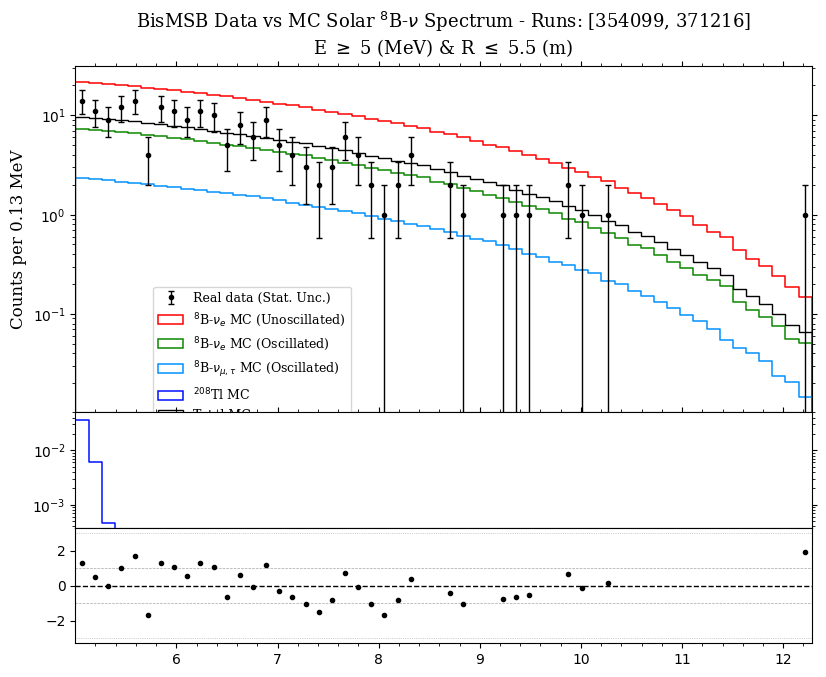

In [40]:
# Define axes: Construct subplots to conveniently represent the low contribution of the 208Tl spectrum
fig, (ax_top, ax_bot, ax_pull) = plt.subplots(3, 1, sharex=True,figsize=(9.5,7.5),
                                     gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0.0})

# --------- Plot functions ---------

# Real data
ax_top.errorbar(bins_center_energy_real_data, energy_counts_non_0,
            yerr=error_bars, fmt='.',
            color='black', label='Real data (Stat. Unc.)',
            elinewidth=1, capsize=2)

# MC components
sn.histplot(x=energy_corr_b8_Nue_mc, bins=energy_bins, weights=np.ones(len(energy_corr_b8_Nue_mc))*scaling_mc_b8_unosc_Nue,
            element='step', alpha=0, ax=ax_top, label=r'$^8$B-$\nu_e$ MC (Unoscillated)', color = '#ff0000', linewidth = linewidth)

sn.histplot(x=energy_corr_b8_osc_Nue_mc_rs, bins=energy_bins, weights =  np.ones(len(energy_corr_b8_osc_Nue_mc_rs))*scaling_mc_b8_osc_Nue_rs,
            element='step', alpha=0, ax=ax_top, label=r'$^8$B-$\nu_e$ MC (Oscillated)', color = '#0b8700', linewidth = linewidth)

sn.histplot(x=energy_corr_b8_Numu_mc, bins=energy_bins, weights=np.ones(len(energy_corr_b8_Numu_mc))*scaling_mc_b8_osc_Numu,
            element='step', alpha=0, ax=ax_top, label=r'$^8$B-$\nu_{\mu,\tau}$ MC (Oscillated)', color = '#0091ff', linewidth = linewidth)

sn.histplot(x=energy_corr_tl208_mc, bins=energy_bins, weights=np.ones(len(energy_corr_tl208_mc))*scaling_mc_tl208,
            element='step', alpha=0, ax=ax_bot, label=r'$^{208}$Tl MC', color = '#0011ff', linewidth = linewidth)

ax_top.hist(bins_center_energy, bins = energy_bins, weights = total_mc_counts, histtype='step', 
            color='black', linewidth=1.0, label='Total MC')

# Pull
ax_pull.errorbar(bins_center_energy_real_data, pull_bin, fmt='o', color='black', markersize=3, elinewidth=1)


# Líneas de referencia (0 es el ajuste perfecto, +/- 1, 2, 3 son las sigmas)
ax_pull.axhline(0, color='black', linestyle='--', linewidth=1)
ax_pull.axhline(1, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax_pull.axhline(-1, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax_pull.axhline(3, color='gray', linestyle=':', linewidth=0.5, alpha=0.7)
ax_pull.axhline(-3, color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

# --------- Axes Settings ---------
#Scale
ax_top.set_yscale('log')
ax_bot.set_yscale('log')

#Ticks
set_ticks(ax_top)
set_ticks(ax_bot)

#axis limits
ax_top.set_xlim(edges[0], edges[-1])
ax_bot.set_ylim(0, 5e-2)

# --------- Titles ---------

ax_bot.set_xlabel('Energy (MeV)', fontdict = font_style_axis)
ax_top.set_ylabel(f'Counts per {binwidth} MeV', fontdict = font_style_axis)
ax_bot.set_ylabel('')

# ---- Build a single legend combining both axes ----
#Order to appear the Legends
order = ['Real data (Stat. Unc.)',
         r'$^8$B-$\nu_e$ MC (Unoscillated)',
         r'$^8$B-$\nu_e$ MC (Oscillated)',
         #r'$^8$B-$\nu_{\mu,\tau}$ MC (Unoscillated)',
         r'$^8$B-$\nu_{\mu,\tau}$ MC (Oscillated)',
         r'$^{208}$Tl MC',
         'Total MC'
         ]

handles_top, labels_top = ax_top.get_legend_handles_labels()
handles_bot, labels_bot = ax_bot.get_legend_handles_labels()

handles = handles_top + handles_bot
labels  = labels_top  + labels_bot

label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[l] for l in order]

ax_top.legend(ordered_handles, order, bbox_to_anchor=(0.24, 0.38), prop = font_prop)
# ------------------ end of common legends-------------------

ax_top.set_title(fr'BisMSB Data vs MC Solar $^8$B-$\nu$ Spectrum - Runs: [354099, 371216]' +  '\n'+  fr'E $\geq$ 5 (MeV) & R $\leq$ {posr_cut*10**(-3)} (m)', fontdict = font_style_title, y = 1.01)

#plt.savefig(save_path + f'energy_spec_MC_vs_Data_E_{en_inf_cut}_MeV_R_{posr_cut}_mm.png', dpi=300, bbox_inches='tight')

plt.show()

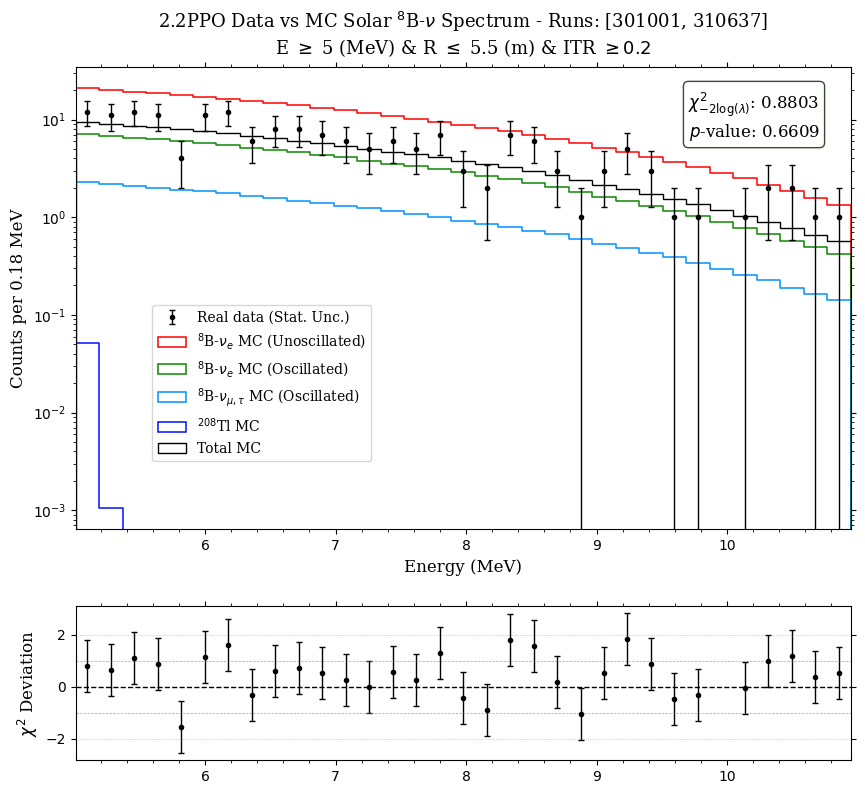

In [48]:
# Define axes: Construct subplots to conveniently represent the low contribution of the 208Tl spectrum
fig, (ax_top, ax_bot) = plt.subplots(2, 1,figsize=(10,9),
                                     gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.25})

# --------- Plot functions ---------

# Real data
ax_top.errorbar(bins_center_energy_real_data, energy_counts_non_0,
            yerr=error_bars, fmt='.',
            color='black', label='Real data (Stat. Unc.)',
            elinewidth=1, capsize=2)

# MC components
sn.histplot(x=energy_corr_b8_Nue_mc, bins=energy_bins, weights=np.ones(len(energy_corr_b8_Nue_mc))*scaling_mc_b8_unosc_Nue,
            element='step', alpha=0, ax=ax_top, label=r'$^8$B-$\nu_e$ MC (Unoscillated)', color = '#ff0000', linewidth = linewidth)

sn.histplot(x=energy_corr_b8_osc_Nue_mc_rs, bins=energy_bins, weights =  np.ones(len(energy_corr_b8_osc_Nue_mc_rs))*scaling_mc_b8_osc_Nue_rs,
            element='step', alpha=0, ax=ax_top, label=r'$^8$B-$\nu_e$ MC (Oscillated)', color = '#0b8700', linewidth = linewidth)

sn.histplot(x=energy_corr_b8_Numu_mc, bins=energy_bins, weights=np.ones(len(energy_corr_b8_Numu_mc))*scaling_mc_b8_osc_Numu,
            element='step', alpha=0, ax=ax_top, label=r'$^8$B-$\nu_{\mu,\tau}$ MC (Oscillated)', color = '#0091ff', linewidth = linewidth)

sn.histplot(x=energy_corr_tl208_mc, bins=energy_bins, weights=np.ones(len(energy_corr_tl208_mc))*scaling_mc_tl208,
            element='step', alpha=0, ax=ax_top, label=r'$^{208}$Tl MC', color = '#0011ff', linewidth = linewidth)

ax_top.hist(bins_center_energy, bins = energy_bins, weights = total_mc_counts, histtype='step', 
            color='black', linewidth=1.0, label='Total MC')

# Pull
ax_bot.errorbar(bins_center_energy_real_data, pull_bin, 
                yerr=1, # El error de un pull siempre es 1
                fmt='o', color='black', markersize=3, 
                elinewidth=1, capsize=2)


# Líneas de referencia (0 es el ajuste perfecto, +/- 1, 2, 3 son las sigmas)
ax_bot.axhline(0, color='black', linestyle='--', linewidth=1)
ax_bot.axhline(1, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax_bot.axhline(-1, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax_bot.axhline(2, color='gray', linestyle=':', linewidth=0.5, alpha=0.7)
ax_bot.axhline(-2, color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

# --------- Axes Settings ---------
#Scale
ax_top.set_yscale('log')
#ax_bot.set_yscale('log')

#Ticks
set_ticks(ax_top)
set_ticks(ax_bot)

#axis limits
ax_top.set_xlim(edges[0], edges[-1])
ax_bot.set_xlim(edges[0], edges[-1])
#ax_bot.set_ylim(0, 5e-2)

# --------- Titles ---------

ax_top.set_xlabel('Energy (MeV)', fontdict = font_style_axis)
ax_top.set_ylabel(f'Counts per {binwidth} MeV', fontdict = font_style_axis)
ax_bot.set_ylabel(r'$\chi^2$ Deviation', fontdict = font_style_axis)

# ---- Build a single legend combining both axes ----
#Order to appear the Legends
order = ['Real data (Stat. Unc.)',
         r'$^8$B-$\nu_e$ MC (Unoscillated)',
         r'$^8$B-$\nu_e$ MC (Oscillated)',
         #r'$^8$B-$\nu_{\mu,\tau}$ MC (Unoscillated)',
         r'$^8$B-$\nu_{\mu,\tau}$ MC (Oscillated)',
         r'$^{208}$Tl MC',
         'Total MC',
         ]

handles_top, labels_top = ax_top.get_legend_handles_labels()

handles = handles_top 
labels  = labels_top  

label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[l] for l in order]

ax_top.legend(ordered_handles, order, bbox_to_anchor=(0.09, 0.5), prop = font_prop)


# ---- Statistical Info Box (Top Right) ----
stats_text = (rf"$\chi^{{2}}_{{-2\text{{log}}(\lambda)}}$: {reduced_chi2:.4f}" + "\n" +
              rf"$p$-value: {p_value:.4f}")

# Box properties
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#071c02')

# Insertar el texto en el gráfico
# transform=ax_top.transAxes hace que (0,0) sea abajo-izquierda y (1,1) arriba-derecha
ax_top.text(0.96, 0.95, stats_text, transform = ax_top.transAxes,
            verticalalignment='top', horizontalalignment='right', 
            fontdict = font_style_axis, bbox=props)

# ------------------ end of common legends-------------------

ax_top.set_title(fr'2.2PPO Data vs MC Solar $^8$B-$\nu$ Spectrum - Runs: [301001, 310637]' +  '\n'+  fr'E $\geq$ {en_inf_cut} (MeV) & R $\leq$ {posr_cut*10**(-3)} (m) & ITR $\geq {itr_cut}$', fontdict = font_style_title, y = 1.01)

plt.savefig(save_path + f'energy_spec_MC_vs_Data_E_{en_inf_cut}_MeV_R_{posr_cut}_mm_ITR_{itr_cut}.png', dpi=300, bbox_inches='tight')

plt.show()

In [49]:
max(pull_bin)

1.830340837958738

# Ratio and Residual Energy Plot (between different normalizations)

The idea is to plot the ratio between the counts on each energy bin of the histograms normalized by two different ways in an attempt to represent MC oscillations:
- One normalization use uniquely the number of expected events with oscillations (without applying Pee directly). (norm1)
- The other uses the number of expected events unoscillations, with the normalization by Pee. (norm2)

Ratio = counts(norm1)/counts(norm2)

Residual = counts(norm1) - counts(norm2)